### This is the notebook for analyzing LUAD data

In [1]:
import numpy as np
import pandas as pd
import anndata as ad
from scipy.sparse import csr_matrix

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_curve, auc, RocCurveDisplay
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.feature_selection import SelectKBest, f_classif

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import seaborn as sns

import gseapy as gp
from gseapy import barplot, dotplot
from gseapy import Msigdb

import mygene
mg = mygene.MyGeneInfo()

import sys
sys.path.append("..")

from scripts.utility_functions import t_test, clean_data, read_data

cancer_type = "CCRCC"
#omic_type = "proteomics"
omic_type = "RNAseq"

##### Step 1: organize the data into anndata object

In [2]:
df_transposed = read_data(cancer_type, omic_type)

In [3]:
df_transposed

idx,ENSG00000000003.15,ENSG00000000005.6,ENSG00000000419.12,ENSG00000000457.14,ENSG00000000460.17,ENSG00000000938.13,ENSG00000000971.16,ENSG00000001036.14,ENSG00000001084.13,ENSG00000001167.14,...,ENSG00000288594.1,ENSG00000288595.1,ENSG00000288596.1,ENSG00000288597.1,ENSG00000288598.1,ENSG00000288600.1,ENSG00000288601.1,ENSG00000288602.1,ENSG00000288603.1,ENSG00000288604.1
C3L-00004_N,11.5916,4.7516,9.5519,9.6819,7.4231,7.1035,11.3116,10.8617,10.3117,10.1918,...,0.0000,4.0776,7.1235,7.9226,6.2750,0.0000,0.0,7.6729,1.3884,3.3875
C3L-00010_N,11.5115,5.1554,9.5021,9.9019,7.8735,6.6762,10.4617,10.9516,10.5817,9.7320,...,0.0000,4.6414,6.8956,7.4043,6.3873,1.2047,0.0,7.0352,0.7275,0.0000
C3L-00011_N,10.6817,3.8941,9.2420,9.7719,7.0540,6.2558,11.4616,11.0116,10.6617,9.7619,...,0.8231,4.8531,7.2736,7.7530,6.8544,0.0000,0.0,7.2936,0.0000,2.4057
C3L-00026_N,11.4816,5.5586,9.5119,9.8918,7.8130,7.0640,11.0016,10.9617,10.5917,10.0918,...,0.0000,4.7737,7.0839,7.7630,6.5151,0.8231,0.0,6.8344,1.7258,2.6072
C3L-00079_N,11.1716,8.3424,9.1820,9.7318,7.8027,7.5430,12.1016,11.2116,10.6817,10.2118,...,1.7821,5.2685,7.5729,8.0326,6.2551,1.7821,0.0,7.7028,1.3884,0.0000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
C3N-01646_T,10.2018,2.0560,9.6919,9.5519,8.1726,7.9627,12.3516,10.6817,9.9818,9.9018,...,0.0000,4.3860,7.6430,7.7529,5.8468,1.7539,0.0,7.0737,0.8407,0.0000
C3N-01648_T,7.9724,1.4384,9.5518,10.0018,8.1923,11.0817,12.2516,11.1317,10.7717,10.4217,...,1.4384,3.3812,7.6726,7.3428,6.3041,2.8108,0.0,8.2922,0.0000,3.9052
C3N-01649_T,9.9018,1.7468,9.7319,9.5319,8.6523,8.7422,12.6116,10.1218,10.5517,10.2318,...,0.0000,5.1801,7.1736,7.6530,6.3752,0.8362,0.0,7.9228,1.3577,0.0000
C3N-01651_T,10.1218,0.0000,9.6718,9.9718,8.6921,7.4329,14.1516,11.3816,11.3316,10.1718,...,0.0000,5.5267,7.4329,8.1824,6.1249,1.4132,0.0,7.6727,2.1172,0.0000


In [4]:
### Make the anndata object
obs=pd.DataFrame(
    index=df_transposed.index, 
    data={
        'SampleType': df_transposed.index.str[-1],  # Last character
        'Sample': df_transposed.index.str[:-2]      # All but last two characters
    }
)

var=pd.DataFrame(
    index=df_transposed.columns, 
    data={
        "ensembl_ids_clean" : [x.split(".")[0] for x in df_transposed.columns]
    }
)

adata = ad.AnnData(
    X=df_transposed,
    obs=obs,
    var=var
)

print(adata)

AnnData object with n_obs × n_vars = 175 × 60669
    obs: 'SampleType', 'Sample'
    var: 'ensembl_ids_clean'


In [5]:
adata.var

,ensembl_ids_clean
idx,
ENSG00000000003.15,ENSG00000000003
ENSG00000000005.6,ENSG00000000005
ENSG00000000419.12,ENSG00000000419
ENSG00000000457.14,ENSG00000000457
ENSG00000000460.17,ENSG00000000460
...,...
ENSG00000288600.1,ENSG00000288600
ENSG00000288601.1,ENSG00000288601
ENSG00000288602.1,ENSG00000288602


In [6]:
### Get gene symbol for ensembl ids (cleaned)
gene_info = mg.querymany(adata.var['ensembl_ids_clean'], scopes="ensembl.gene", fields = "symbol", species="human")
gene_symbols = {item['query']: item.get('symbol', None) for item in gene_info}

# Create a DataFrame to map Ensembl IDs to Gene Symbols
gene_mapping = pd.DataFrame(list(gene_symbols.items()), columns=['ensembl_ids_clean', 'Gene'])

# Merge with adata.var to add Gene_Symbol
adata.var = adata.var.join(gene_mapping.set_index("ensembl_ids_clean"), on='ensembl_ids_clean', how='left')

assert (adata.var.index == df_transposed.columns).all()
assert (adata.obs.index == df_transposed.index).all()

Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
73 input query terms found dup hits:	[('ENSG00000002586', 2), ('ENSG00000124333', 2), ('ENSG00000124334', 2), ('ENSG00000167393', 2), ('E
1314 input query terms found no hit:	['ENSG00000002079', 'ENSG00000112096', 'ENSG00000130723', 'ENSG00000131484', 'ENSG00000132832', 'ENS


In [7]:
adata.var_names
adata.var
#adata.obs


,ensembl_ids_clean,Gene
idx,,
ENSG00000000003.15,ENSG00000000003,TSPAN6
ENSG00000000005.6,ENSG00000000005,TNMD
ENSG00000000419.12,ENSG00000000419,DPM1
ENSG00000000457.14,ENSG00000000457,SCYL3
ENSG00000000460.17,ENSG00000000460,FIRRM
...,...,...
ENSG00000288600.1,ENSG00000288600,None
ENSG00000288601.1,ENSG00000288601,RNA5SP424
ENSG00000288602.1,ENSG00000288602,C8orf44-SGK3


In [8]:
### Select only protein coding genes
if omic_type == "RNAseq":
    gene_function = pd.read_csv("../../MultiOmics_cancer_landscape_data/proteinatlas.tsv", sep="\t")
    gene_function = gene_function.loc[:, ["Gene", "Ensembl", "Protein class", "Gene description"]]
    
    gene_function = gene_function.drop_duplicates(subset=['Ensembl'], keep='first')
    gene_function

    ori_index = adata.var.index

    # Merge into AnnData
    adata.var = adata.var.merge(
        gene_function,
        left_on = "ensembl_ids_clean",
        right_on="Ensembl",      # merge using the gene name column
        how="left",
        suffixes=('', '_proteinatlas')
    )

    adata.var = adata.var.set_index(ori_index)
    
    valid_genes_mask = adata.var['Gene_proteinatlas'].notna()

    adata = adata[:, valid_genes_mask].copy()

    print(f"Original number of genes: {len(valid_genes_mask)}")
    print(f"Number of genes remaining after filtering (i.e., successfully annotated): {adata.n_vars}")


Original number of genes: 60669
Number of genes remaining after filtering (i.e., successfully annotated): 20052


In [9]:

adata.var

,ensembl_ids_clean,Gene,Gene_proteinatlas,Ensembl,Protein class,Gene description
idx,,,,,,
ENSG00000000003.15,ENSG00000000003,TSPAN6,TSPAN6,ENSG00000000003,Predicted membrane proteins,Tetraspanin 6
ENSG00000000005.6,ENSG00000000005,TNMD,TNMD,ENSG00000000005,Predicted membrane proteins,Tenomodulin
ENSG00000000419.12,ENSG00000000419,DPM1,DPM1,ENSG00000000419,"Disease related genes, Enzymes, Human disease ...",Dolichyl-phosphate mannosyltransferase subunit...
ENSG00000000457.14,ENSG00000000457,SCYL3,SCYL3,ENSG00000000457,"Enzymes, Predicted intracellular proteins",SCY1 like pseudokinase 3
ENSG00000000460.17,ENSG00000000460,FIRRM,C1orf112,ENSG00000000460,Predicted intracellular proteins,Chromosome 1 open reading frame 112
...,...,...,...,...,...,...
ENSG00000288529.1,ENSG00000288529,LOC128092253,ENSG00000288529,ENSG00000288529,Predicted intracellular proteins,Novel protein
ENSG00000288558.1,ENSG00000288558,DUS4L-BCAP29,DUS4L-BCAP29,ENSG00000288558,Predicted membrane proteins,DUS4L-BCAP29 readthrough
ENSG00000288570.1,ENSG00000288570,LOC128092248,ENSG00000288570,ENSG00000288570,Predicted intracellular proteins,Novel protein


In [10]:
adata.var

,ensembl_ids_clean,Gene,Gene_proteinatlas,Ensembl,Protein class,Gene description
idx,,,,,,
ENSG00000000003.15,ENSG00000000003,TSPAN6,TSPAN6,ENSG00000000003,Predicted membrane proteins,Tetraspanin 6
ENSG00000000005.6,ENSG00000000005,TNMD,TNMD,ENSG00000000005,Predicted membrane proteins,Tenomodulin
ENSG00000000419.12,ENSG00000000419,DPM1,DPM1,ENSG00000000419,"Disease related genes, Enzymes, Human disease ...",Dolichyl-phosphate mannosyltransferase subunit...
ENSG00000000457.14,ENSG00000000457,SCYL3,SCYL3,ENSG00000000457,"Enzymes, Predicted intracellular proteins",SCY1 like pseudokinase 3
ENSG00000000460.17,ENSG00000000460,FIRRM,C1orf112,ENSG00000000460,Predicted intracellular proteins,Chromosome 1 open reading frame 112
...,...,...,...,...,...,...
ENSG00000288529.1,ENSG00000288529,LOC128092253,ENSG00000288529,ENSG00000288529,Predicted intracellular proteins,Novel protein
ENSG00000288558.1,ENSG00000288558,DUS4L-BCAP29,DUS4L-BCAP29,ENSG00000288558,Predicted membrane proteins,DUS4L-BCAP29 readthrough
ENSG00000288570.1,ENSG00000288570,LOC128092248,ENSG00000288570,ENSG00000288570,Predicted intracellular proteins,Novel protein


In [11]:
object_file = f"../../MultiOmics_cancer_landscape_data/{cancer_type}/Object/{cancer_type}_{omic_type}.h5ad"

adata.write(object_file, compression="gzip")

In [11]:
adata.obs["SampleType"].value_counts()

SampleType
T    103
N     72
Name: count, dtype: int64

##### Step 2: ML

In [22]:
### Main ML workflow 

# Load data
object_file = f"../../MultiOmics_cancer_landscape_data/{cancer_type}/Object/{cancer_type}_{omic_type}.h5ad"
adata = ad.read_h5ad(object_file)

X = adata.X
y_ori = adata.obs["SampleType"].values
#samples = adata.obs["Sample"].values  # sample names or IDs
samples_type = adata.obs["SampleType"].values
samples = adata.obs.index

# Encode labels
# LabelEncoder assigns integers alphabetically by default, so if your labels are "N" and "T" you’ll usually get "Normal" = 0, "Tumor" = 1
encoder = LabelEncoder()
y = encoder.fit_transform(y_ori)

# Ensure "Normal" = 0, "Tumor" = 1
if encoder.transform(["T"])[0] == 0:
    y = 1 - y  # flip labels

# Split train/test and also get the indices of the test set
X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X, y, range(len(y)), test_size=0.3, random_state=42, stratify=y, shuffle=True
)

adata_train = adata[samples[idx_train], ]
adata_test = adata[samples[idx_test], ]

# Train Random Forest
rf = RandomForestClassifier(n_estimators=500, random_state=42)
rf.fit(X_train, y_train)

adata_train = t_test(adata_obj = adata_train, sample_type_col= "SampleType", left_type = "T", right_type="N")

adata_train.var["feature_importance"] = rf.feature_importances_


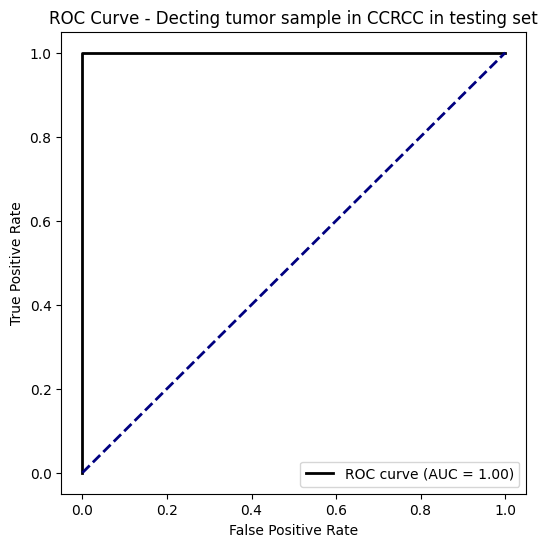

In [24]:

### Prediction
y_proba = rf.predict_proba(X_test)[:, 1]  # Probability of class 1 (Tumor)

# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_proba)

# Compute AUC
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, color = "black", lw=2, label=f"ROC curve (AUC = {roc_auc:.2f})")
plt.plot([0,1], [0,1], color = "navy", lw=2, linestyle= "--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve - Decting tumor sample in {cancer_type} in testing set")
plt.legend(loc="lower right")

# Save to PDF
pdf_file = f"../results/figures/{cancer_type}_{omic_type}_ROC_in_testing_set.pdf"
plt.savefig(pdf_file, format="pdf", bbox_inches="tight")

plt.show()


    idx_test       Sample Sample_Type  y_test  y_pred
0         94  C3N-00831_T           T       1   0.986
1         71  C3N-00852_N           N       0   0.044
2        171  C3N-00437_T           T       1   0.958
3         88  C3L-01861_T           T       1   0.916
4         69  C3N-01522_N           N       0   0.004
5         29  C3L-01885_N           N       0   0.006
6        127  C3N-01649_T           T       1   0.974
7         32  C3L-00447_N           N       0   0.002
8         21  C3L-00004_N           N       0   0.022
9         24  C3N-00244_N           N       0   0.004
10        37  C3L-00902_N           N       0   0.010
11       144  C3N-01648_T           T       1   0.782
12       160  C3L-00792_T           T       1   0.968
13       150  C3N-01522_T           T       1   0.984
14       142  C3N-01179_T           T       1   0.976
15        52  C3N-01361_N           N       0   0.004
16        63  C3L-00418_N           N       0   0.004
17        23  C3N-00150_N   

/var/folders/fw/7fvd0mjd5zn0z9v4wq8_h6ww0000gn/T/ipykernel_44667/88673498.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=performance, x="Sample_Type", y="y_pred", palette=custom_palette)


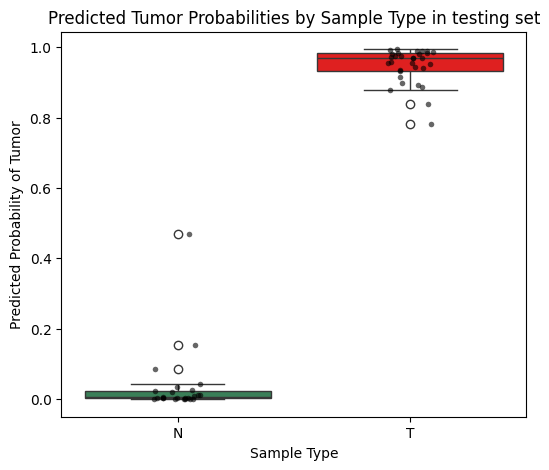

In [25]:

### Create performance DataFrame with Sample info and visualize the proba in testing set
performance = pd.DataFrame({
    "idx_test": idx_test,
    "Sample": samples[idx_test],   # sample names
    "Sample_Type": samples_type[idx_test],
    "y_test": y_test,
    "y_pred": y_proba
})

print(performance)

performance_sort = performance.sort_values("y_pred").reset_index(drop=True)

#pd.set_option("display.max_rows", None)
#print(performance_sort)

### Boxplot on the prediction score in testing set
custom_palette = {"N": "seagreen", "T": "red"}

plt.figure(figsize=(6,5))
sns.boxplot(data=performance, x="Sample_Type", y="y_pred", palette=custom_palette)
sns.stripplot(data=performance, x="Sample_Type", y="y_pred", color="black", size=4, jitter=True, alpha=0.6)
plt.ylabel("Predicted Probability of Tumor")
plt.xlabel("Sample Type")
plt.title("Predicted Tumor Probabilities by Sample Type in testing set")

# Save to PDF
pdf_file = f"../results/figures/{cancer_type}_{omic_type}_Proba_in_testing_set.pdf"
plt.savefig(pdf_file, format="pdf", bbox_inches="tight")

plt.show()

In [26]:
feature_importance_sort = adata_train.var.sort_values(by="feature_importance", ascending=False)
feature_importance_sort.head(5)

,ensembl_ids_clean,Gene,left_mean,right_mean,diff_mean,t_vals,p_vals,feature_importance
idx,,,,,,,,
ENSG00000067057.17,ENSG00000067057,PFKP,28.808971662175257,26.9346946463214,1.874277,30.746867,1.100832e-58,0.014000
ENSG00000119655.11,ENSG00000119655,NPC2,27.06275961591938,28.907594481831065,-1.844835,-23.046749,1.165260e-40,0.012000
ENSG00000196498.13,ENSG00000196498,NCOR2,23.908604291799065,23.125152287293208,0.783452,25.321682,8.799959e-50,0.011995
ENSG00000145715.15,ENSG00000145715,RASA1,24.52834951245511,24.053837669539625,0.474512,20.143395,3.013825e-39,0.011748
ENSG00000131828.14,ENSG00000131828,PDHA1,26.35805208075195,27.66368794170815,-1.305636,-28.516234,1.793231e-54,0.010000


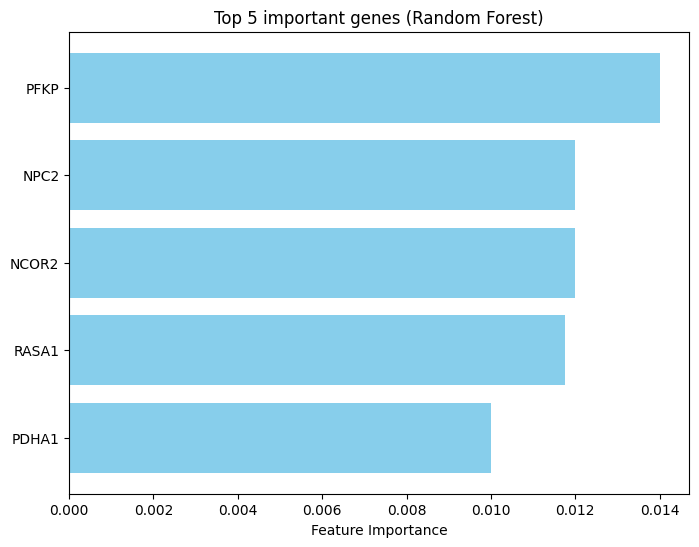

In [27]:
top_n = 5
plt.figure(figsize=(8,6))
plt.barh(
    feature_importance_sort['Gene'][:top_n][::-1],
    feature_importance_sort['feature_importance'][:top_n][::-1],
    color='skyblue'
)
plt.xlabel("Feature Importance")
plt.title(f"Top {top_n} important genes (Random Forest)")
plt.show()


#### Step 3: Explore the features with biological input

/var/folders/fw/7fvd0mjd5zn0z9v4wq8_h6ww0000gn/T/ipykernel_44667/3707500470.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


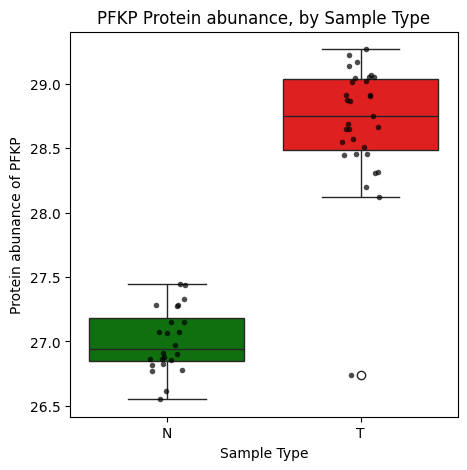

/var/folders/fw/7fvd0mjd5zn0z9v4wq8_h6ww0000gn/T/ipykernel_44667/3707500470.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


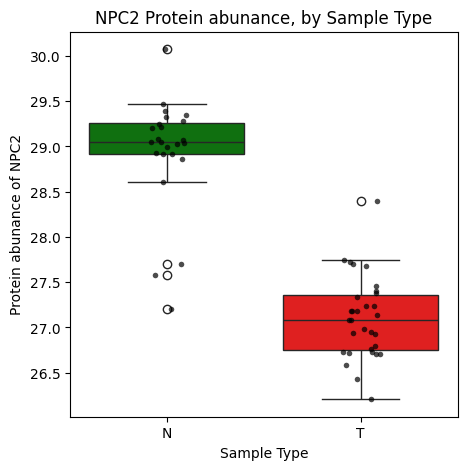

/var/folders/fw/7fvd0mjd5zn0z9v4wq8_h6ww0000gn/T/ipykernel_44667/3707500470.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


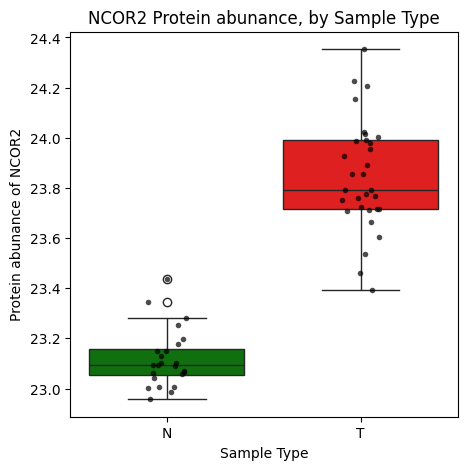

/var/folders/fw/7fvd0mjd5zn0z9v4wq8_h6ww0000gn/T/ipykernel_44667/3707500470.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


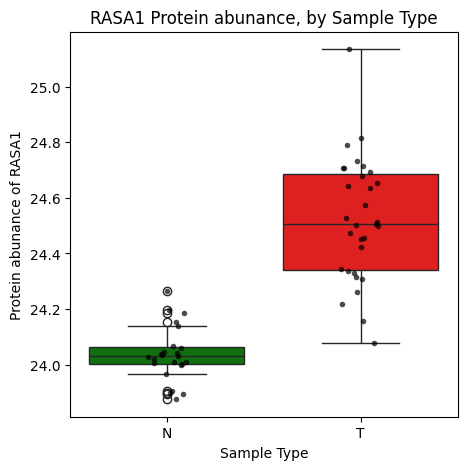

/var/folders/fw/7fvd0mjd5zn0z9v4wq8_h6ww0000gn/T/ipykernel_44667/3707500470.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


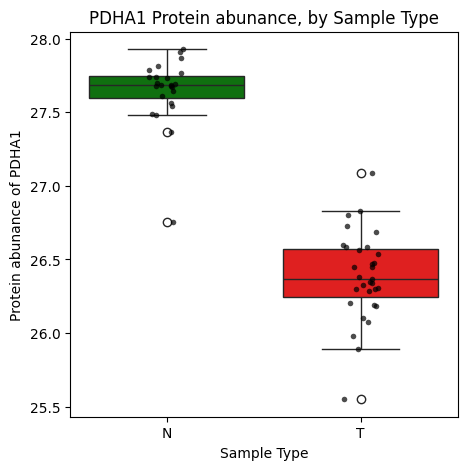

In [28]:
### Boxplot on important genes in testing set
selected_genes = feature_importance_sort.iloc[0:5, ].index.to_list()

df = pd.DataFrame(
    adata_test.X, 
    index=adata_test.obs.index,
    columns=adata_test.var.index  # or adata.var['Gene'] if you prefer gene symbols
).join(adata_test.obs)


for gene in selected_genes:
    plt.figure(figsize=(5,5))
    sns.boxplot(
        data=df, 
        x="SampleType", 
        y=gene, 
        palette={"N": "green", "T": "red"}
    )
    sns.stripplot(
        data=df, 
        x="SampleType", 
        y=gene, 
        color="black", 
        size=4, 
        jitter=True, 
        alpha=0.7
    )
    plt.ylabel(f"Protein abunance of {adata.var.loc[gene, 'Gene']}")
    plt.xlabel("Sample Type")
    plt.title(f"{adata.var.loc[gene, 'Gene']} Protein abunance, by Sample Type")
    plt.show()



Total number of samples: 55


/Users/wzhang/miniforge3/envs/C2S/lib/python3.8/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/Users/wzhang/miniforge3/envs/C2S/lib/python3.8/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


<Figure size 900x900 with 0 Axes>

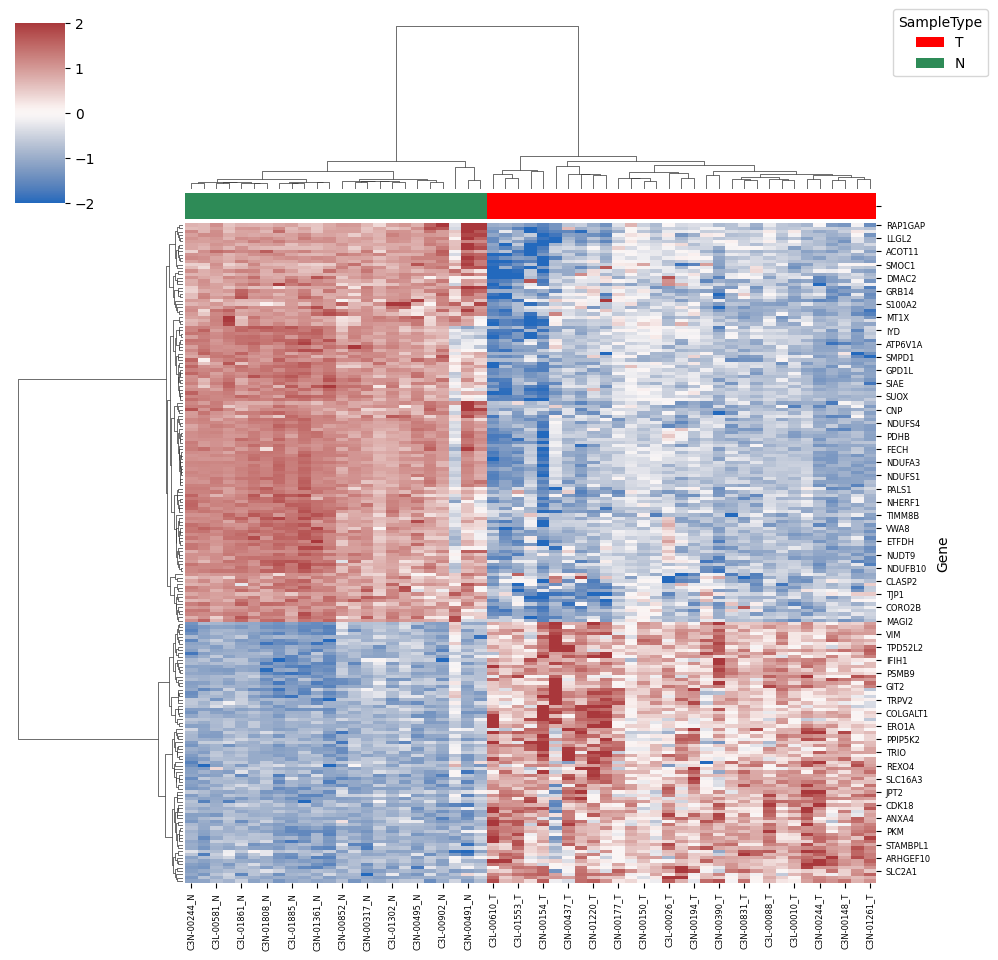

In [29]:
### TODO: only can heatmap visualize the top 100 genes
### Heatmap on top 200 important genes on testing set

selected_genes = feature_importance_sort.iloc[0:200, ].index.to_list()
adata_test_selected_genes = adata_test[:, selected_genes]

scaler = StandardScaler()
df_scaled = pd.DataFrame(
    scaler.fit_transform(adata_test_selected_genes.X),
    columns=adata_test_selected_genes.var["Gene"],    # genes
    index=adata_test_selected_genes.obs.index   # samples
)
df_scaled_T = df_scaled.T
# Map disease status to colors
disease_status_col = "SampleType"
lut = {"T": "red", "N": "seagreen"}
dict_colors = adata_test_selected_genes.obs[disease_status_col].map(lut).to_dict()
col_colors = pd.Series(dict_colors)[df_scaled_T.columns]

print(f"Total number of samples: {len(col_colors)}")

# Cluster map
fig = plt.figure(figsize =(9,9))
g= sns.clustermap(
    df_scaled_T,
    col_colors=col_colors,
    cmap="vlag",
    method="ward",
    center=0,
    vmin=-2,
    vmax=2,
    xticklabels=True,
    yticklabels=True
)
# Option 2: Skip some labels (subsample)
yticks = g.ax_heatmap.get_yticks()              # tick positions
ylabels = [lab.get_text() for lab in g.ax_heatmap.get_yticklabels()]  # label texts

skip = 4  # show every 5th gene
g.ax_heatmap.set_yticks(yticks[::skip])
g.ax_heatmap.set_yticklabels(ylabels[::skip], fontsize=6, rotation=0)

# Option 2: Skip some labels (subsample)
xticks = g.ax_heatmap.get_xticks()              # tick positions
xlabels = [lab.get_text() for lab in g.ax_heatmap.get_xticklabels()]  # label texts

skip = 2  # show every 5th gene
g.ax_heatmap.set_xticks(xticks[::skip])
g.ax_heatmap.set_xticklabels(xlabels[::skip], fontsize=6, rotation=90)


# Legend
handles = [Patch(facecolor=lut[name]) for name in lut]
plt.legend(
    handles,
    lut,
    title=disease_status_col,
    bbox_to_anchor=(1, 1),
    bbox_transform=plt.gcf().transFigure,
    loc="upper right"
)
plt.show()


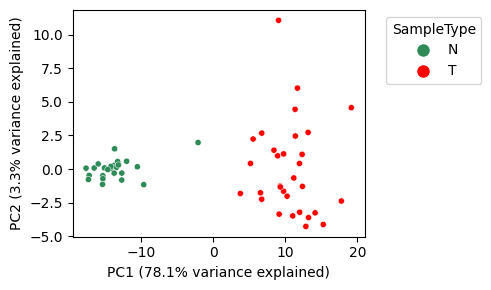

In [30]:

### PCA on top 200 important genes on testing set

scaler = StandardScaler()
df_scaled = scaler.fit_transform(adata_test_selected_genes.X)
pca = PCA()
pca_result = pca.fit_transform(df_scaled)

df_pca = pd.DataFrame(
    data = pca_result[:, :2],
    columns= ['PC1', 'PC2'],
    index = adata_test_selected_genes.obs.index
).join(adata_test_selected_genes.obs)

var_explained = pca.explained_variance_ratio_ * 100

disease_status_col = "SampleType"

color_dict = {
    'T': 'red',      # Red
    'N': 'seagreen'   # Green
}
legend_order = ['N', 'T']

fig = plt.figure(figsize =(6,3))
sns.scatterplot(
    data = df_pca,
    x = 'PC1',
    y = 'PC2',
    hue = disease_status_col,
    s = 20,
    palette=color_dict
)

plt.xlabel(f'PC1 ({var_explained[0]:.1f}% variance explained)')
plt.ylabel(f'PC2 ({var_explained[1]:.1f}% variance explained)')

# Create handles and labels in the specific order
handles = []
labels = []
for category in legend_order:
    if category in color_dict:  # Make sure the category exists in your dictionary
        handles.append(plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color_dict[category], markersize=10))
        labels.append(category)

# Create the legend with the ordered handles and labels
plt.legend(handles, labels, title=disease_status_col, bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout(rect=[0, 0, 0.85, 1])  
plt.show()



/var/folders/fw/7fvd0mjd5zn0z9v4wq8_h6ww0000gn/T/ipykernel_44667/2067379197.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  glist = feature_importance_sort.iloc[0:200, ][feature_importance_sort["diff_mean"] > 0]["Gene"].to_list()


               Gene_set                               Term Overlap  \
0  MSigDB_Hallmark_2020                         Glycolysis  10/200   
1  MSigDB_Hallmark_2020                            Hypoxia   8/200   
2  MSigDB_Hallmark_2020          Interferon Gamma Response   6/200   
3  MSigDB_Hallmark_2020  Epithelial Mesenchymal Transition   6/200   
4  MSigDB_Hallmark_2020          Interferon Alpha Response    4/97   

        P-value  Adjusted P-value  Old P-value  Old Adjusted P-value  \
0  6.314985e-09      2.210245e-07            0                     0   
1  1.235111e-06      2.161443e-05            0                     0   
2  1.405957e-04      1.230212e-03            0                     0   
3  1.405957e-04      1.230212e-03            0                     0   
4  5.913148e-04      4.139204e-03            0                     0   

   Odds Ratio  Combined Score  \
0   15.050343      284.155605   
1   11.578052      157.511868   
2    8.357718       74.129801   
3    8.357718 

<Axes: title={'center': 'UpRegulated 79 proteins from top 200 features'}, xlabel='$- \\log_{10}$ (Adjusted P-value)'>

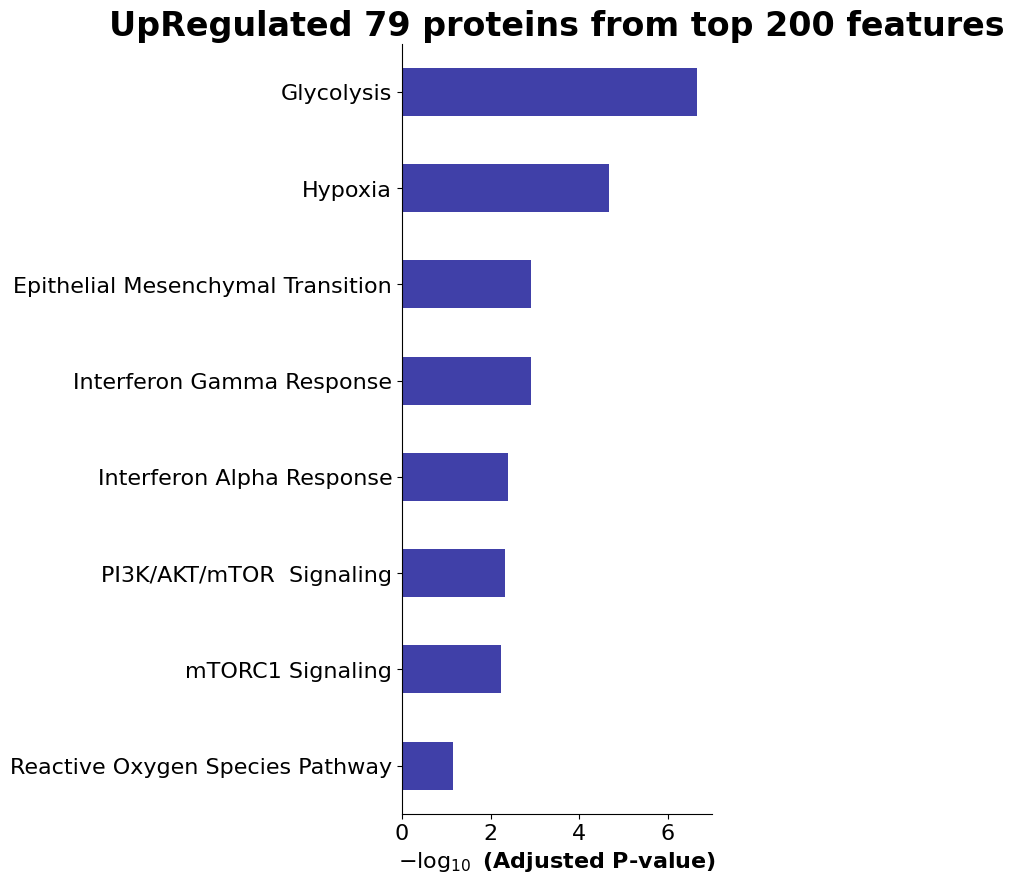

In [31]:
feature_importance_sort = adata_train.var.sort_values(by="feature_importance", ascending=False)
glist = feature_importance_sort.iloc[0:200, ][feature_importance_sort["diff_mean"] > 0]["Gene"].to_list()
# if you are only intrested in dataframe that enrichr returned, please set outdir=None
enr = gp.enrichr(gene_list=glist, # or "./tests/data/gene_list.txt",
                 gene_sets=['MSigDB_Hallmark_2020'],
                 organism='human', # don't forget to set organism to the one you desired! e.g. Yeast
                 outdir=None, # don't write to disk
                )
print(enr.results.head(5))
barplot(enr.results, cutoff=0.1, title=f'UpRegulated {len(glist)} proteins from top 200 features', figsize=(4, 10), color='darkblue')

/var/folders/fw/7fvd0mjd5zn0z9v4wq8_h6ww0000gn/T/ipykernel_44667/3322754241.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  glist = feature_importance_sort.iloc[0:200, ][feature_importance_sort["diff_mean"] < 0]["Gene"].to_list()


               Gene_set                             Term Overlap  \
0  MSigDB_Hallmark_2020        Oxidative Phosphorylation  24/200   
1  MSigDB_Hallmark_2020                     Adipogenesis   7/200   
2  MSigDB_Hallmark_2020            Fatty Acid Metabolism   5/158   
3  MSigDB_Hallmark_2020  Reactive Oxygen Species Pathway    3/49   
4  MSigDB_Hallmark_2020                Protein Secretion    3/96   

        P-value  Adjusted P-value  Old P-value  Old Adjusted P-value  \
0  1.428883e-24      4.000874e-23            0                     0   
1  2.172946e-04      3.042125e-03            0                     0   
2  2.751282e-03      2.274446e-02            0                     0   
3  3.249208e-03      2.274446e-02            0                     0   
4  2.053596e-02      1.150014e-01            0                     0   

   Odds Ratio  Combined Score  \
0   27.698688     1520.800585   
1    6.263158       52.825079   
2    5.557246       32.763789   
3   10.961496       62.802

<Axes: title={'center': 'DownRegulated 121 proteins from top 200 features'}, xlabel='$- \\log_{10}$ (Adjusted P-value)'>

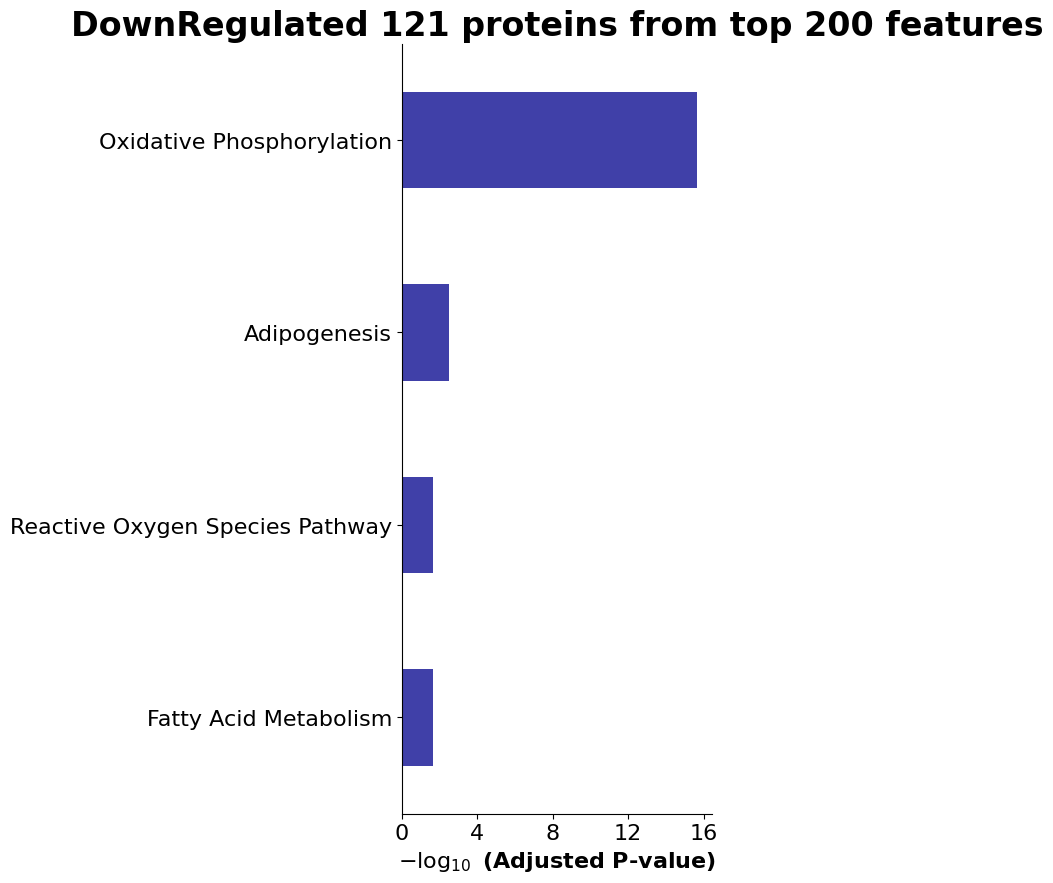

In [32]:
feature_importance_sort = adata_train.var.sort_values(by="feature_importance", ascending=False)
glist = feature_importance_sort.iloc[0:200, ][feature_importance_sort["diff_mean"] < 0]["Gene"].to_list()
# if you are only intrested in dataframe that enrichr returned, please set outdir=None
enr = gp.enrichr(gene_list=glist, # or "./tests/data/gene_list.txt",
                 gene_sets=['MSigDB_Hallmark_2020'],
                 organism='human', # don't forget to set organism to the one you desired! e.g. Yeast
                 outdir=None, # don't write to disk
                )
print(enr.results.head(5))
barplot(enr.results, cutoff=0.1, title=f'DownRegulated {len(glist)} proteins from top 200 features', figsize=(4, 10), color='darkblue')